# Majority Voting & Perfect Agreement

Notebook ini membuat **2 dataset final** dari hasil 3 annotator:

## Output 1: Perfect Agreement (Bebas Konflik)
- **SEMUA 3 annotator 100% setuju** (category DAN sentiment sama persis)
- Jika ada **1 saja perbedaan** → baris dihapus

## Output 2: Majority Voting  
- **Minimal 2 dari 3 annotator setuju**
- Kategori/sentiment dipilih berdasarkan suara mayoritas
- Jika **semua 3 berbeda** (konflik total) → baris dihapus

In [16]:
# Import libraries
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [17]:
# Load data dari 3 annotator
df1 = pd.read_csv('very_clean_dataset/annotator1_clean.csv')
df2 = pd.read_csv('very_clean_dataset/annotator2_clean.csv')
df3 = pd.read_csv('very_clean_dataset/annotator3_clean.csv')

print(f"Annotator 1: {len(df1)} rows")
print(f"Annotator 2: {len(df2)} rows")
print(f"Annotator 3: {len(df3)} rows")
print("\nSample dari Annotator 1:")
df1.head()

Annotator 1: 38345 rows
Annotator 2: 38345 rows
Annotator 3: 38345 rows

Sample dari Annotator 1:


,sentence_id,at,content,category,sentiment
0,review_1_1,2025-10-30 23:58:11,"Map suka eror,, driver dimana map dimana..biki...",app,negative
1,review_2_1,2025-10-30 23:42:51,terlalu mahal skrg.,service,negative
2,review_3_1,2025-10-30 23:34:57,bolehh lah,none,positive
3,review_4_1,2025-10-30 23:28:26,love you gojek....always the best😍,service,positive
4,review_5_1,2025-10-30 23:06:34,mantap gojek,service,positive


In [18]:
# Merge data dari 3 annotator berdasarkan sentence_id
df1_renamed = df1.rename(columns={'category': 'category_1', 'sentiment': 'sentiment_1'})
df2_renamed = df2.rename(columns={'category': 'category_2', 'sentiment': 'sentiment_2'})
df3_renamed = df3.rename(columns={'category': 'category_3', 'sentiment': 'sentiment_3'})

merged = df1_renamed[['sentence_id', 'at', 'content', 'category_1', 'sentiment_1']].merge(
    df2_renamed[['sentence_id', 'category_2', 'sentiment_2']], 
    on='sentence_id', 
    how='inner'
).merge(
    df3_renamed[['sentence_id', 'category_3', 'sentiment_3']], 
    on='sentence_id', 
    how='inner'
)

print(f"Merged dataset: {len(merged)} rows")
print("\nSample merged data:")
merged.head(10)

Merged dataset: 38345 rows

Sample merged data:


,sentence_id,at,content,category_1,sentiment_1,category_2,sentiment_2,category_3,sentiment_3
0,review_1_1,2025-10-30 23:58:11,"Map suka eror,, driver dimana map dimana..biki...",app,negative,app,negative,app dan service,negative
1,review_2_1,2025-10-30 23:42:51,terlalu mahal skrg.,service,negative,service,negative,app,negative
2,review_3_1,2025-10-30 23:34:57,bolehh lah,none,positive,none,positive,none,neutral
3,review_4_1,2025-10-30 23:28:26,love you gojek....always the best😍,service,positive,service,positive,service,positive
4,review_5_1,2025-10-30 23:06:34,mantap gojek,service,positive,service,positive,service,positive
5,review_6_1,2025-10-30 23:01:26,siip,none,positive,none,positive,none,positive
6,review_7_1,2025-10-30 22:33:30,"keren, sangat membantu makasih gojek",service,positive,service,positive,service,positive
7,review_8_1,2025-10-30 21:49:06,kalau order gofod jam pagi driver nya masih pa...,service,negative,service,negative,service,negative
8,review_9_1,2025-10-30 19:45:27,kasi harga yg bnr la gjls bgt goride gd 2 kilo...,app,negative,app,negative,app,negative
9,review_10_1,2025-10-30 18:28:38,Mantap drivernya ramah sopan pokoknya 🌟 5,service,positive,service,positive,service,positive


In [19]:
# Fungsi untuk majority voting
def get_majority_vote(values):
    """
    Mengembalikan nilai mayoritas dari list.
    Jika semua berbeda, return None (konflik).
    Jika ada 2 yang sama, return nilai mayoritas.
    """
    counter = Counter(values)
    most_common = counter.most_common(1)[0]
    
    # Jika nilai terbanyak muncul >= 2 kali, itu mayoritas
    if most_common[1] >= 2:
        return most_common[0]
    else:
        # Semua berbeda (konflik)
        return None

print("✓ Fungsi majority voting sudah didefinisikan")

✓ Fungsi majority voting sudah didefinisikan


## Output 1: Perfect Agreement (Bebas Konflik)

Dataset ini berisi data dimana **SEMUA 3 annotator 100% setuju** (category DAN sentiment sama persis).

**Kriteria:**
- Category: annotator1 = annotator2 = annotator3
- Sentiment: annotator1 = annotator2 = annotator3
- Jika ada **1 saja perbedaan** → HAPUS baris

In [20]:
# Output 1: Perfect Agreement
merged['category_perfect'] = (merged['category_1'] == merged['category_2']) & (merged['category_2'] == merged['category_3'])
merged['sentiment_perfect'] = (merged['sentiment_1'] == merged['sentiment_2']) & (merged['sentiment_2'] == merged['sentiment_3'])
merged['is_perfect_agreement'] = merged['category_perfect'] & merged['sentiment_perfect']

dataset_perfect_agreement = merged[merged['is_perfect_agreement'] == True][
    ['sentence_id', 'at', 'content', 'category_1', 'sentiment_1']
].copy()
dataset_perfect_agreement = dataset_perfect_agreement.rename(columns={
    'category_1': 'category', 
    'sentiment_1': 'sentiment'
})

print(f"✓ Dataset Perfect Agreement: {len(dataset_perfect_agreement)} rows")
print(f"  Data dihapus: {len(merged) - len(dataset_perfect_agreement)} rows")
print(f"  Persentase: {len(dataset_perfect_agreement)/len(merged)*100:.2f}%")
print("\nSample Perfect Agreement:")
dataset_perfect_agreement.head()

✓ Dataset Perfect Agreement: 16747 rows
  Data dihapus: 21598 rows
  Persentase: 43.67%

Sample Perfect Agreement:


,sentence_id,at,content,category,sentiment
3,review_4_1,2025-10-30 23:28:26,love you gojek....always the best😍,service,positive
4,review_5_1,2025-10-30 23:06:34,mantap gojek,service,positive
5,review_6_1,2025-10-30 23:01:26,siip,none,positive
6,review_7_1,2025-10-30 22:33:30,"keren, sangat membantu makasih gojek",service,positive
7,review_8_1,2025-10-30 21:49:06,kalau order gofod jam pagi driver nya masih pa...,service,negative


## Output 2: Majority Voting

Dataset ini berisi data dimana **minimal 2 dari 3 annotator setuju**.

**Kriteria:**
- Category: minimal 2 annotator setuju → ambil nilai mayoritas
- Sentiment: minimal 2 annotator setuju → ambil nilai mayoritas  
- Jika **semua 3 berbeda** (di category ATAU sentiment) → HAPUS baris

In [21]:
# Output 2: Majority Voting
merged['category_majority'] = merged.apply(
    lambda row: get_majority_vote([row['category_1'], row['category_2'], row['category_3']]), 
    axis=1
)
merged['sentiment_majority'] = merged.apply(
    lambda row: get_majority_vote([row['sentiment_1'], row['sentiment_2'], row['sentiment_3']]), 
    axis=1
)
merged['has_conflict'] = (merged['category_majority'].isna()) | (merged['sentiment_majority'].isna())

dataset_majority_voting = merged[merged['has_conflict'] == False][
    ['sentence_id', 'at', 'content', 'category_majority', 'sentiment_majority']
].copy()
dataset_majority_voting = dataset_majority_voting.rename(columns={
    'category_majority': 'category', 
    'sentiment_majority': 'sentiment'
})

print(f"✓ Dataset Majority Voting: {len(dataset_majority_voting)} rows")
print(f"  Data dihapus: {len(merged) - len(dataset_majority_voting)} rows")
print(f"  Persentase: {len(dataset_majority_voting)/len(merged)*100:.2f}%")
print("\nSample Majority Voting:")
dataset_majority_voting.head()

✓ Dataset Majority Voting: 35897 rows
  Data dihapus: 2448 rows
  Persentase: 93.62%

Sample Majority Voting:


,sentence_id,at,content,category,sentiment
0,review_1_1,2025-10-30 23:58:11,"Map suka eror,, driver dimana map dimana..biki...",app,negative
1,review_2_1,2025-10-30 23:42:51,terlalu mahal skrg.,service,negative
2,review_3_1,2025-10-30 23:34:57,bolehh lah,none,positive
3,review_4_1,2025-10-30 23:28:26,love you gojek....always the best😍,service,positive
4,review_5_1,2025-10-30 23:06:34,mantap gojek,service,positive


In [22]:
# Simpan kedua dataset
dataset_perfect_agreement.to_csv('dataset_perfect_agreement.csv', index=False)
print(f"✓ Dataset Perfect Agreement → dataset_perfect_agreement.csv ({len(dataset_perfect_agreement)} rows)")

dataset_majority_voting.to_csv('dataset_majority_voting.csv', index=False)
print(f"✓ Dataset Majority Voting → dataset_majority_voting.csv ({len(dataset_majority_voting)} rows)")

✓ Dataset Perfect Agreement → dataset_perfect_agreement.csv (16747 rows)
✓ Dataset Majority Voting → dataset_majority_voting.csv (35897 rows)


## Analisis Perbedaan Kedua Dataset

Bandingkan **Perfect Agreement** vs **Majority Voting**:
1. Perbedaan jumlah baris
2. Perbedaan distribusi category
3. Perbedaan distribusi sentiment
4. Visualisasi perbandingan

In [23]:
# 1. PERBEDAAN JUMLAH BARIS
print("="*80)
print("1. PERBEDAAN JUMLAH BARIS")
print("="*80)

jumlah_total = len(merged)
jumlah_perfect = len(dataset_perfect_agreement)
jumlah_majority = len(dataset_majority_voting)

print(f"Data awal (total):            {jumlah_total:,} rows (100.00%)")
print(f"Perfect Agreement (output 1): {jumlah_perfect:,} rows ({jumlah_perfect/jumlah_total*100:.2f}%)")
print(f"Majority Voting (output 2):   {jumlah_majority:,} rows ({jumlah_majority/jumlah_total*100:.2f}%)")
print(f"\nSelisih kedua output:         {jumlah_majority - jumlah_perfect:,} rows")
print(f"Majority lebih banyak:        {(jumlah_majority - jumlah_perfect)/jumlah_perfect*100:.2f}% dari Perfect")

1. PERBEDAAN JUMLAH BARIS
Data awal (total):            38,345 rows (100.00%)
Perfect Agreement (output 1): 16,747 rows (43.67%)
Majority Voting (output 2):   35,897 rows (93.62%)

Selisih kedua output:         19,150 rows
Majority lebih banyak:        114.35% dari Perfect


In [24]:
# 2. PERBEDAAN DISTRIBUSI CATEGORY
print("\n" + "="*80)
print("2. PERBEDAAN DISTRIBUSI CATEGORY")
print("="*80)

category_perfect = dataset_perfect_agreement['category'].value_counts().sort_index()
category_majority = dataset_majority_voting['category'].value_counts().sort_index()

comparison_category = pd.DataFrame({
    'Perfect Agreement': category_perfect,
    'Majority Voting': category_majority
}).fillna(0).astype(int)

comparison_category['Selisih'] = comparison_category['Majority Voting'] - comparison_category['Perfect Agreement']
comparison_category['% Tambahan'] = (comparison_category['Selisih'] / comparison_category['Perfect Agreement'] * 100).round(2)

print("\nDistribusi Category:")
print(comparison_category)
print(f"\nTotal: Perfect={comparison_category['Perfect Agreement'].sum():,} | Majority={comparison_category['Majority Voting'].sum():,}")


2. PERBEDAAN DISTRIBUSI CATEGORY

Distribusi Category:
                 Perfect Agreement  Majority Voting  Selisih  % Tambahan
category                                                                
app                           4005             9531     5526      137.98
app dan service                 10              181      171     1710.00
none                          8599            15625     7026       81.71
service                       4133            10560     6427      155.50

Total: Perfect=16,747 | Majority=35,897


In [25]:
# 3. PERBEDAAN DISTRIBUSI SENTIMENT
print("\n" + "="*80)
print("3. PERBEDAAN DISTRIBUSI SENTIMENT")
print("="*80)

sentiment_perfect = dataset_perfect_agreement['sentiment'].value_counts().sort_index()
sentiment_majority = dataset_majority_voting['sentiment'].value_counts().sort_index()

comparison_sentiment = pd.DataFrame({
    'Perfect Agreement': sentiment_perfect,
    'Majority Voting': sentiment_majority
}).fillna(0).astype(int)

comparison_sentiment['Selisih'] = comparison_sentiment['Majority Voting'] - comparison_sentiment['Perfect Agreement']
comparison_sentiment['% Tambahan'] = (comparison_sentiment['Selisih'] / comparison_sentiment['Perfect Agreement'] * 100).round(2)

print("\nDistribusi Sentiment:")
print(comparison_sentiment)
print(f"\nTotal: Perfect={comparison_sentiment['Perfect Agreement'].sum():,} | Majority={comparison_sentiment['Majority Voting'].sum():,}")


3. PERBEDAAN DISTRIBUSI SENTIMENT

Distribusi Sentiment:
           Perfect Agreement  Majority Voting  Selisih  % Tambahan
sentiment                                                         
negative                6594            15798     9204      139.58
neutral                   90             2379     2289     2543.33
positive               10063            17720     7657       76.09

Total: Perfect=16,747 | Majority=35,897


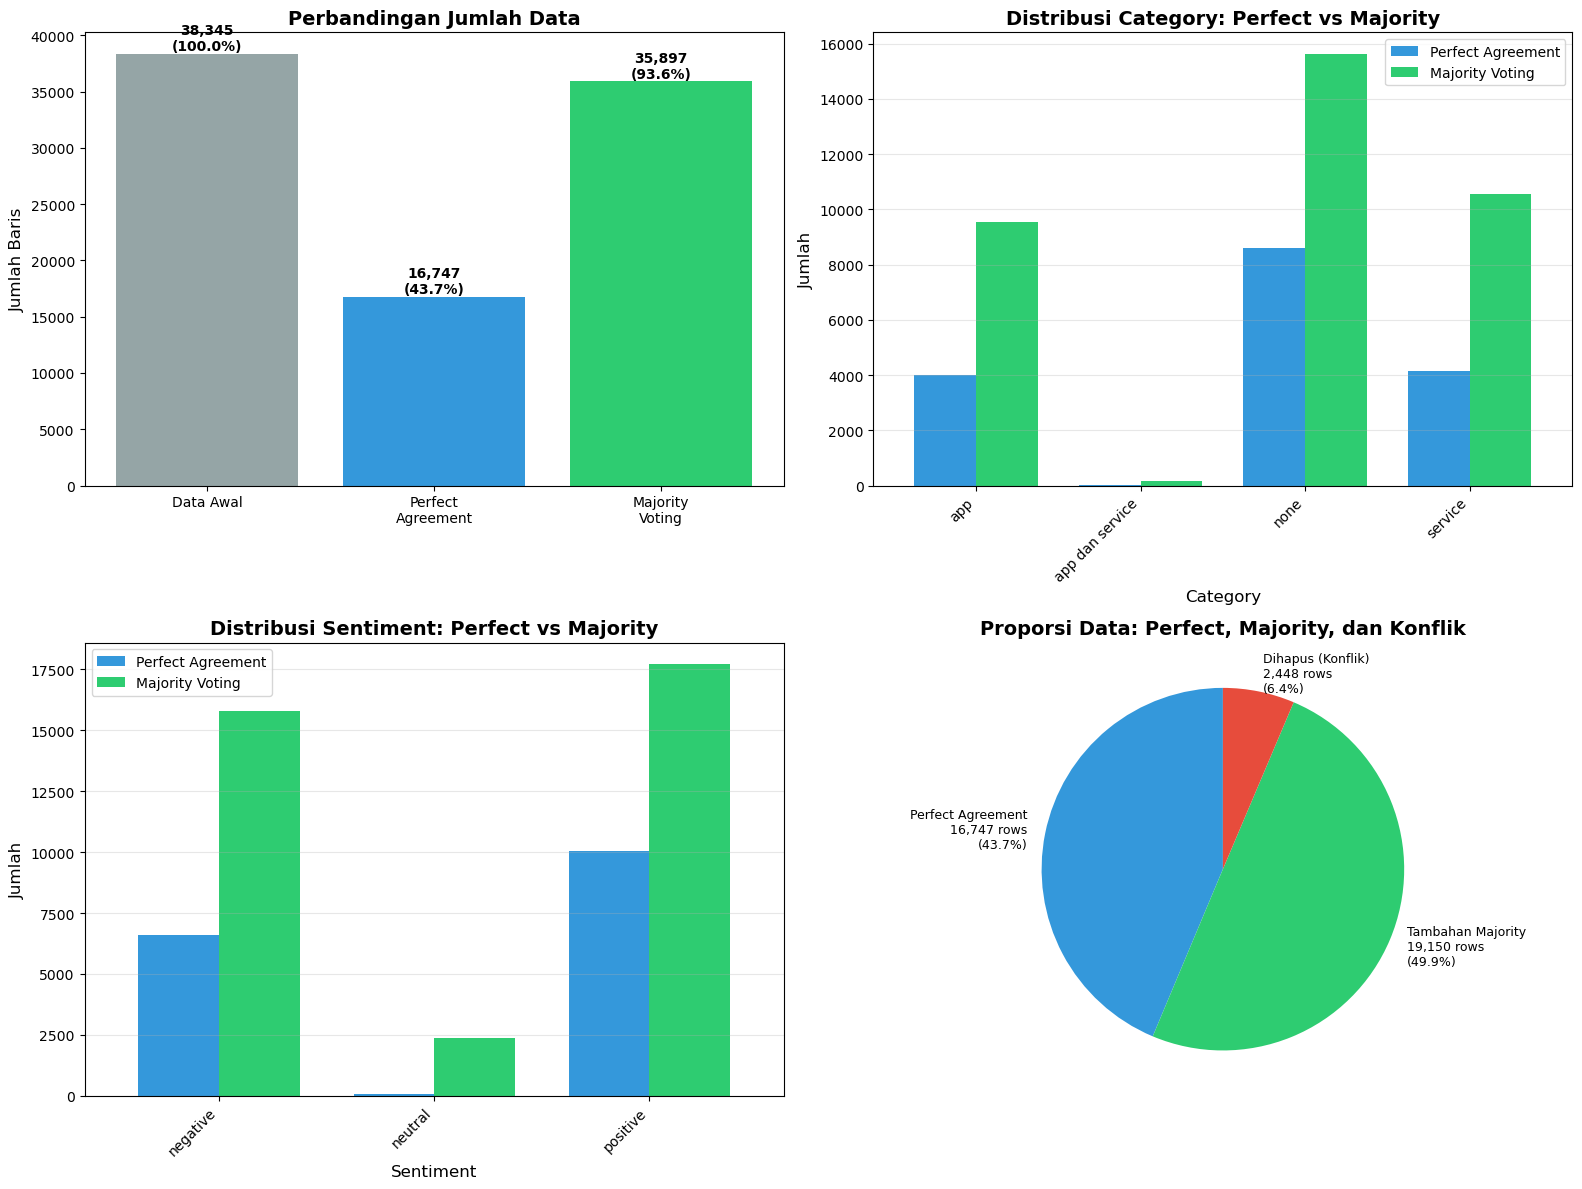


✓ Visualisasi disimpan: comparison_perfect_vs_majority.png


In [26]:
# 4. VISUALISASI PERBANDINGAN
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Jumlah Total Data
ax1 = axes[0, 0]
categories_bar = ['Data Awal', 'Perfect\nAgreement', 'Majority\nVoting']
values_bar = [jumlah_total, jumlah_perfect, jumlah_majority]
colors_bar = ['#95a5a6', '#3498db', '#2ecc71']
bars = ax1.bar(categories_bar, values_bar, color=colors_bar)
ax1.set_ylabel('Jumlah Baris', fontsize=12)
ax1.set_title('Perbandingan Jumlah Data', fontsize=14, fontweight='bold')
for bar, val in zip(bars, values_bar):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{val:,}\n({val/jumlah_total*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 2: Distribusi Category
ax2 = axes[0, 1]
comparison_category[['Perfect Agreement', 'Majority Voting']].plot(
    kind='bar', ax=ax2, color=['#3498db', '#2ecc71'], width=0.75
)
ax2.set_ylabel('Jumlah', fontsize=12)
ax2.set_title('Distribusi Category: Perfect vs Majority', fontsize=14, fontweight='bold')
ax2.legend(['Perfect Agreement', 'Majority Voting'], fontsize=10)
ax2.set_xlabel('Category', fontsize=12)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Distribusi Sentiment
ax3 = axes[1, 0]
comparison_sentiment[['Perfect Agreement', 'Majority Voting']].plot(
    kind='bar', ax=ax3, color=['#3498db', '#2ecc71'], width=0.75
)
ax3.set_ylabel('Jumlah', fontsize=12)
ax3.set_title('Distribusi Sentiment: Perfect vs Majority', fontsize=14, fontweight='bold')
ax3.legend(['Perfect Agreement', 'Majority Voting'], fontsize=10)
ax3.set_xlabel('Sentiment', fontsize=12)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Pie chart
ax4 = axes[1, 1]
pie_labels = [
    f'Perfect Agreement\n{jumlah_perfect:,} rows\n({jumlah_perfect/jumlah_total*100:.1f}%)',
    f'Tambahan Majority\n{jumlah_majority-jumlah_perfect:,} rows\n({(jumlah_majority-jumlah_perfect)/jumlah_total*100:.1f}%)',
    f'Dihapus (Konflik)\n{jumlah_total-jumlah_majority:,} rows\n({(jumlah_total-jumlah_majority)/jumlah_total*100:.1f}%)'
]
pie_values = [jumlah_perfect, jumlah_majority-jumlah_perfect, jumlah_total-jumlah_majority]
pie_colors = ['#3498db', '#2ecc71', '#e74c3c']
ax4.pie(pie_values, labels=pie_labels, colors=pie_colors, startangle=90, textprops={'fontsize': 9})
ax4.set_title('Proporsi Data: Perfect, Majority, dan Konflik', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_perfect_vs_majority.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Visualisasi disimpan: comparison_perfect_vs_majority.png")

In [27]:
# RINGKASAN AKHIR
print("\n" + "="*80)
print("RINGKASAN HASIL")
print("="*80)

print("\n📊 FILE OUTPUT:")
print("   1. dataset_perfect_agreement.csv")
print("      → Semua 3 annotator 100% setuju")
print(f"      → {jumlah_perfect:,} rows ({jumlah_perfect/jumlah_total*100:.2f}%)")
print("\n   2. dataset_majority_voting.csv")
print("      → Minimal 2 dari 3 annotator setuju")
print(f"      → {jumlah_majority:,} rows ({jumlah_majority/jumlah_total*100:.2f}%)")
print("\n   3. comparison_perfect_vs_majority.png")
print("      → Visualisasi perbandingan")

print("\n📈 STATISTIK:")
print(f"   • Data awal:            {jumlah_total:,} rows")
print(f"   • Perfect Agreement:    {jumlah_perfect:,} rows")
print(f"   • Majority Voting:      {jumlah_majority:,} rows")
print(f"   • Selisih:              {jumlah_majority - jumlah_perfect:,} rows ({(jumlah_majority-jumlah_perfect)/jumlah_perfect*100:.2f}% lebih banyak)")
print(f"   • Data dihapus konflik: {jumlah_total-jumlah_majority:,} rows")

print("\n✅ Selesai!")


RINGKASAN HASIL

📊 FILE OUTPUT:
   1. dataset_perfect_agreement.csv
      → Semua 3 annotator 100% setuju
      → 16,747 rows (43.67%)

   2. dataset_majority_voting.csv
      → Minimal 2 dari 3 annotator setuju
      → 35,897 rows (93.62%)

   3. comparison_perfect_vs_majority.png
      → Visualisasi perbandingan

📈 STATISTIK:
   • Data awal:            38,345 rows
   • Perfect Agreement:    16,747 rows
   • Majority Voting:      35,897 rows
   • Selisih:              19,150 rows (114.35% lebih banyak)
   • Data dihapus konflik: 2,448 rows

✅ Selesai!


In [28]:
# RINGKASAN AKHIR
print("\n" + "="*80)
print("RINGKASAN HASIL")
print("="*80)

print("\n📊 FILE OUTPUT:")
print("   1. dataset_perfect_agreement.csv")
print("      → Semua 3 annotator 100% setuju")
print(f"      → {jumlah_perfect:,} rows ({jumlah_perfect/jumlah_total*100:.2f}%)")
print("\n   2. dataset_majority_voting.csv")
print("      → Minimal 2 dari 3 annotator setuju")
print(f"      → {jumlah_majority:,} rows ({jumlah_majority/jumlah_total*100:.2f}%)")
print("\n   3. comparison_perfect_vs_majority.png")
print("      → Visualisasi perbandingan")

print("\n📈 STATISTIK:")
print(f"   • Data awal:            {jumlah_total:,} rows")
print(f"   • Perfect Agreement:    {jumlah_perfect:,} rows")
print(f"   • Majority Voting:      {jumlah_majority:,} rows")
print(f"   • Selisih:              {jumlah_majority - jumlah_perfect:,} rows ({(jumlah_majority-jumlah_perfect)/jumlah_perfect*100:.2f}% lebih banyak)")
print(f"   • Data dihapus konflik: {jumlah_total-jumlah_majority:,} rows")

print("\n✅ Selesai!")


RINGKASAN HASIL

📊 FILE OUTPUT:
   1. dataset_perfect_agreement.csv
      → Semua 3 annotator 100% setuju
      → 16,747 rows (43.67%)

   2. dataset_majority_voting.csv
      → Minimal 2 dari 3 annotator setuju
      → 35,897 rows (93.62%)

   3. comparison_perfect_vs_majority.png
      → Visualisasi perbandingan

📈 STATISTIK:
   • Data awal:            38,345 rows
   • Perfect Agreement:    16,747 rows
   • Majority Voting:      35,897 rows
   • Selisih:              19,150 rows (114.35% lebih banyak)
   • Data dihapus konflik: 2,448 rows

✅ Selesai!


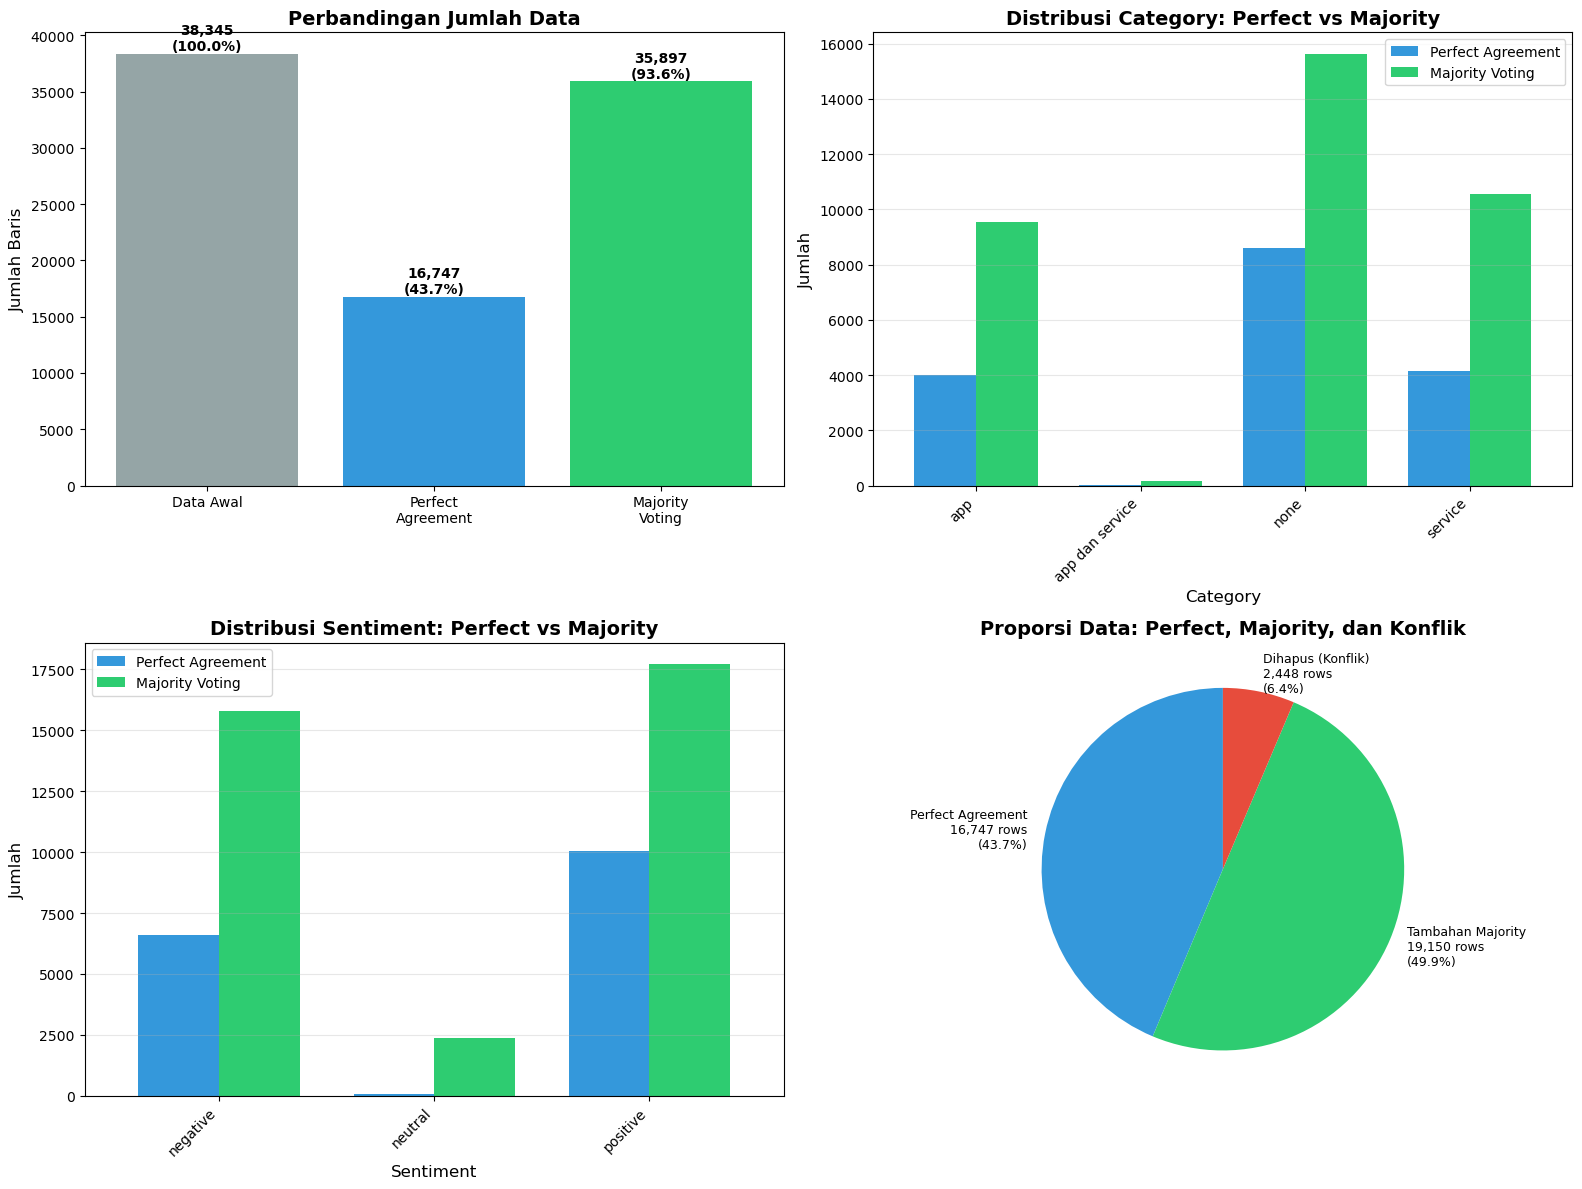


✓ Visualisasi disimpan: comparison_perfect_vs_majority.png


In [29]:
# 4. VISUALISASI PERBANDINGAN
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Jumlah Total Data
ax1 = axes[0, 0]
categories_bar = ['Data Awal', 'Perfect\nAgreement', 'Majority\nVoting']
values_bar = [jumlah_total, jumlah_perfect, jumlah_majority]
colors_bar = ['#95a5a6', '#3498db', '#2ecc71']
bars = ax1.bar(categories_bar, values_bar, color=colors_bar)
ax1.set_ylabel('Jumlah Baris', fontsize=12)
ax1.set_title('Perbandingan Jumlah Data', fontsize=14, fontweight='bold')
for bar, val in zip(bars, values_bar):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{val:,}\n({val/jumlah_total*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 2: Distribusi Category
ax2 = axes[0, 1]
comparison_category[['Perfect Agreement', 'Majority Voting']].plot(
    kind='bar', ax=ax2, color=['#3498db', '#2ecc71'], width=0.75
)
ax2.set_ylabel('Jumlah', fontsize=12)
ax2.set_title('Distribusi Category: Perfect vs Majority', fontsize=14, fontweight='bold')
ax2.legend(['Perfect Agreement', 'Majority Voting'], fontsize=10)
ax2.set_xlabel('Category', fontsize=12)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Distribusi Sentiment
ax3 = axes[1, 0]
comparison_sentiment[['Perfect Agreement', 'Majority Voting']].plot(
    kind='bar', ax=ax3, color=['#3498db', '#2ecc71'], width=0.75
)
ax3.set_ylabel('Jumlah', fontsize=12)
ax3.set_title('Distribusi Sentiment: Perfect vs Majority', fontsize=14, fontweight='bold')
ax3.legend(['Perfect Agreement', 'Majority Voting'], fontsize=10)
ax3.set_xlabel('Sentiment', fontsize=12)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Pie chart
ax4 = axes[1, 1]
pie_labels = [
    f'Perfect Agreement\n{jumlah_perfect:,} rows\n({jumlah_perfect/jumlah_total*100:.1f}%)',
    f'Tambahan Majority\n{jumlah_majority-jumlah_perfect:,} rows\n({(jumlah_majority-jumlah_perfect)/jumlah_total*100:.1f}%)',
    f'Dihapus (Konflik)\n{jumlah_total-jumlah_majority:,} rows\n({(jumlah_total-jumlah_majority)/jumlah_total*100:.1f}%)'
]
pie_values = [jumlah_perfect, jumlah_majority-jumlah_perfect, jumlah_total-jumlah_majority]
pie_colors = ['#3498db', '#2ecc71', '#e74c3c']
ax4.pie(pie_values, labels=pie_labels, colors=pie_colors, startangle=90, textprops={'fontsize': 9})
ax4.set_title('Proporsi Data: Perfect, Majority, dan Konflik', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_perfect_vs_majority.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Visualisasi disimpan: comparison_perfect_vs_majority.png")

In [30]:
# 3. PERBEDAAN DISTRIBUSI SENTIMENT
print("\n" + "="*80)
print("3. PERBEDAAN DISTRIBUSI SENTIMENT")
print("="*80)

sentiment_perfect = dataset_perfect_agreement['sentiment'].value_counts().sort_index()
sentiment_majority = dataset_majority_voting['sentiment'].value_counts().sort_index()

comparison_sentiment = pd.DataFrame({
    'Perfect Agreement': sentiment_perfect,
    'Majority Voting': sentiment_majority
}).fillna(0).astype(int)

comparison_sentiment['Selisih'] = comparison_sentiment['Majority Voting'] - comparison_sentiment['Perfect Agreement']
comparison_sentiment['% Tambahan'] = (comparison_sentiment['Selisih'] / comparison_sentiment['Perfect Agreement'] * 100).round(2)

print("\nDistribusi Sentiment:")
print(comparison_sentiment)
print(f"\nTotal: Perfect={comparison_sentiment['Perfect Agreement'].sum():,} | Majority={comparison_sentiment['Majority Voting'].sum():,}")


3. PERBEDAAN DISTRIBUSI SENTIMENT

Distribusi Sentiment:
           Perfect Agreement  Majority Voting  Selisih  % Tambahan
sentiment                                                         
negative                6594            15798     9204      139.58
neutral                   90             2379     2289     2543.33
positive               10063            17720     7657       76.09

Total: Perfect=16,747 | Majority=35,897


In [31]:
# 2. PERBEDAAN DISTRIBUSI CATEGORY
print("\n" + "="*80)
print("2. PERBEDAAN DISTRIBUSI CATEGORY")
print("="*80)

category_perfect = dataset_perfect_agreement['category'].value_counts().sort_index()
category_majority = dataset_majority_voting['category'].value_counts().sort_index()

comparison_category = pd.DataFrame({
    'Perfect Agreement': category_perfect,
    'Majority Voting': category_majority
}).fillna(0).astype(int)

comparison_category['Selisih'] = comparison_category['Majority Voting'] - comparison_category['Perfect Agreement']
comparison_category['% Tambahan'] = (comparison_category['Selisih'] / comparison_category['Perfect Agreement'] * 100).round(2)

print("\nDistribusi Category:")
print(comparison_category)
print(f"\nTotal: Perfect={comparison_category['Perfect Agreement'].sum():,} | Majority={comparison_category['Majority Voting'].sum():,}")


2. PERBEDAAN DISTRIBUSI CATEGORY

Distribusi Category:
                 Perfect Agreement  Majority Voting  Selisih  % Tambahan
category                                                                
app                           4005             9531     5526      137.98
app dan service                 10              181      171     1710.00
none                          8599            15625     7026       81.71
service                       4133            10560     6427      155.50

Total: Perfect=16,747 | Majority=35,897


In [32]:
# 1. PERBEDAAN JUMLAH BARIS
print("="*80)
print("1. PERBEDAAN JUMLAH BARIS")
print("="*80)

jumlah_total = len(merged)
jumlah_perfect = len(dataset_perfect_agreement)
jumlah_majority = len(dataset_majority_voting)

print(f"Data awal (total):            {jumlah_total:,} rows (100.00%)")
print(f"Perfect Agreement (output 1): {jumlah_perfect:,} rows ({jumlah_perfect/jumlah_total*100:.2f}%)")
print(f"Majority Voting (output 2):   {jumlah_majority:,} rows ({jumlah_majority/jumlah_total*100:.2f}%)")
print(f"\nSelisih kedua output:         {jumlah_majority - jumlah_perfect:,} rows")
print(f"Majority lebih banyak:        {(jumlah_majority - jumlah_perfect)/jumlah_perfect*100:.2f}% dari Perfect")

1. PERBEDAAN JUMLAH BARIS
Data awal (total):            38,345 rows (100.00%)
Perfect Agreement (output 1): 16,747 rows (43.67%)
Majority Voting (output 2):   35,897 rows (93.62%)

Selisih kedua output:         19,150 rows
Majority lebih banyak:        114.35% dari Perfect


## Analisis Perbedaan Kedua Dataset

Bandingkan **Perfect Agreement** vs **Majority Voting**:
1. Perbedaan jumlah baris
2. Perbedaan distribusi category
3. Perbedaan distribusi sentiment
4. Visualisasi perbandingan

In [33]:
# Simpan kedua dataset
dataset_perfect_agreement.to_csv('dataset_perfect_agreement.csv', index=False)
print(f"✓ Dataset Perfect Agreement → dataset_perfect_agreement.csv ({len(dataset_perfect_agreement)} rows)")

dataset_majority_voting.to_csv('dataset_majority_voting.csv', index=False)
print(f"✓ Dataset Majority Voting → dataset_majority_voting.csv ({len(dataset_majority_voting)} rows)")

✓ Dataset Perfect Agreement → dataset_perfect_agreement.csv (16747 rows)
✓ Dataset Majority Voting → dataset_majority_voting.csv (35897 rows)


In [34]:
# Output 2: Majority Voting
merged['category_majority'] = merged.apply(
    lambda row: get_majority_vote([row['category_1'], row['category_2'], row['category_3']]), 
    axis=1
)
merged['sentiment_majority'] = merged.apply(
    lambda row: get_majority_vote([row['sentiment_1'], row['sentiment_2'], row['sentiment_3']]), 
    axis=1
)
merged['has_conflict'] = (merged['category_majority'].isna()) | (merged['sentiment_majority'].isna())

dataset_majority_voting = merged[merged['has_conflict'] == False][
    ['sentence_id', 'at', 'content', 'category_majority', 'sentiment_majority']
].copy()
dataset_majority_voting = dataset_majority_voting.rename(columns={
    'category_majority': 'category', 
    'sentiment_majority': 'sentiment'
})

print(f"✓ Dataset Majority Voting: {len(dataset_majority_voting)} rows")
print(f"  Data dihapus: {len(merged) - len(dataset_majority_voting)} rows")
print(f"  Persentase: {len(dataset_majority_voting)/len(merged)*100:.2f}%")
print("\nSample Majority Voting:")
dataset_majority_voting.head()

✓ Dataset Majority Voting: 35897 rows
  Data dihapus: 2448 rows
  Persentase: 93.62%

Sample Majority Voting:


,sentence_id,at,content,category,sentiment
0,review_1_1,2025-10-30 23:58:11,"Map suka eror,, driver dimana map dimana..biki...",app,negative
1,review_2_1,2025-10-30 23:42:51,terlalu mahal skrg.,service,negative
2,review_3_1,2025-10-30 23:34:57,bolehh lah,none,positive
3,review_4_1,2025-10-30 23:28:26,love you gojek....always the best😍,service,positive
4,review_5_1,2025-10-30 23:06:34,mantap gojek,service,positive


## Output 2: Majority Voting

Dataset ini berisi data dimana **minimal 2 dari 3 annotator setuju**.

**Kriteria:**
- Category: minimal 2 annotator setuju → ambil nilai mayoritas
- Sentiment: minimal 2 annotator setuju → ambil nilai mayoritas  
- Jika **semua 3 berbeda** (di category ATAU sentiment) → HAPUS baris

In [35]:
# Output 1: Perfect Agreement
merged['category_perfect'] = (merged['category_1'] == merged['category_2']) & (merged['category_2'] == merged['category_3'])
merged['sentiment_perfect'] = (merged['sentiment_1'] == merged['sentiment_2']) & (merged['sentiment_2'] == merged['sentiment_3'])
merged['is_perfect_agreement'] = merged['category_perfect'] & merged['sentiment_perfect']

dataset_perfect_agreement = merged[merged['is_perfect_agreement'] == True][
    ['sentence_id', 'at', 'content', 'category_1', 'sentiment_1']
].copy()
dataset_perfect_agreement = dataset_perfect_agreement.rename(columns={
    'category_1': 'category', 
    'sentiment_1': 'sentiment'
})

print(f"✓ Dataset Perfect Agreement: {len(dataset_perfect_agreement)} rows")
print(f"  Data dihapus: {len(merged) - len(dataset_perfect_agreement)} rows")
print(f"  Persentase: {len(dataset_perfect_agreement)/len(merged)*100:.2f}%")
print("\nSample Perfect Agreement:")
dataset_perfect_agreement.head()

✓ Dataset Perfect Agreement: 16747 rows
  Data dihapus: 21598 rows
  Persentase: 43.67%

Sample Perfect Agreement:


,sentence_id,at,content,category,sentiment
3,review_4_1,2025-10-30 23:28:26,love you gojek....always the best😍,service,positive
4,review_5_1,2025-10-30 23:06:34,mantap gojek,service,positive
5,review_6_1,2025-10-30 23:01:26,siip,none,positive
6,review_7_1,2025-10-30 22:33:30,"keren, sangat membantu makasih gojek",service,positive
7,review_8_1,2025-10-30 21:49:06,kalau order gofod jam pagi driver nya masih pa...,service,negative


## Output 1: Perfect Agreement (Bebas Konflik)

Dataset ini berisi data dimana **SEMUA 3 annotator 100% setuju** (category DAN sentiment sama persis).

**Kriteria:**
- Category: annotator1 = annotator2 = annotator3
- Sentiment: annotator1 = annotator2 = annotator3
- Jika ada **1 saja perbedaan** → HAPUS baris

In [36]:
# Fungsi untuk majority voting
def get_majority_vote(values):
    """
    Mengembalikan nilai mayoritas dari list.
    Jika semua berbeda, return None (konflik).
    Jika ada 2 yang sama, return nilai mayoritas.
    """
    counter = Counter(values)
    most_common = counter.most_common(1)[0]
    
    # Jika nilai terbanyak muncul >= 2 kali, itu mayoritas
    if most_common[1] >= 2:
        return most_common[0]
    else:
        # Semua berbeda (konflik)
        return None

print("✓ Fungsi majority voting sudah didefinisikan")

✓ Fungsi majority voting sudah didefinisikan


In [37]:
# Merge data dari 3 annotator berdasarkan sentence_id
df1_renamed = df1.rename(columns={'category': 'category_1', 'sentiment': 'sentiment_1'})
df2_renamed = df2.rename(columns={'category': 'category_2', 'sentiment': 'sentiment_2'})
df3_renamed = df3.rename(columns={'category': 'category_3', 'sentiment': 'sentiment_3'})

merged = df1_renamed[['sentence_id', 'at', 'content', 'category_1', 'sentiment_1']].merge(
    df2_renamed[['sentence_id', 'category_2', 'sentiment_2']], 
    on='sentence_id', 
    how='inner'
).merge(
    df3_renamed[['sentence_id', 'category_3', 'sentiment_3']], 
    on='sentence_id', 
    how='inner'
)

print(f"Merged dataset: {len(merged)} rows")
print("\nSample merged data:")
merged.head(10)

Merged dataset: 38345 rows

Sample merged data:


,sentence_id,at,content,category_1,sentiment_1,category_2,sentiment_2,category_3,sentiment_3
0,review_1_1,2025-10-30 23:58:11,"Map suka eror,, driver dimana map dimana..biki...",app,negative,app,negative,app dan service,negative
1,review_2_1,2025-10-30 23:42:51,terlalu mahal skrg.,service,negative,service,negative,app,negative
2,review_3_1,2025-10-30 23:34:57,bolehh lah,none,positive,none,positive,none,neutral
3,review_4_1,2025-10-30 23:28:26,love you gojek....always the best😍,service,positive,service,positive,service,positive
4,review_5_1,2025-10-30 23:06:34,mantap gojek,service,positive,service,positive,service,positive
5,review_6_1,2025-10-30 23:01:26,siip,none,positive,none,positive,none,positive
6,review_7_1,2025-10-30 22:33:30,"keren, sangat membantu makasih gojek",service,positive,service,positive,service,positive
7,review_8_1,2025-10-30 21:49:06,kalau order gofod jam pagi driver nya masih pa...,service,negative,service,negative,service,negative
8,review_9_1,2025-10-30 19:45:27,kasi harga yg bnr la gjls bgt goride gd 2 kilo...,app,negative,app,negative,app,negative
9,review_10_1,2025-10-30 18:28:38,Mantap drivernya ramah sopan pokoknya 🌟 5,service,positive,service,positive,service,positive


In [38]:
# Load data dari 3 annotator
df1 = pd.read_csv('very_clean_dataset/annotator1_clean.csv')
df2 = pd.read_csv('very_clean_dataset/annotator2_clean.csv')
df3 = pd.read_csv('very_clean_dataset/annotator3_clean.csv')

print(f"Annotator 1: {len(df1)} rows")
print(f"Annotator 2: {len(df2)} rows")
print(f"Annotator 3: {len(df3)} rows")
print("\nSample dari Annotator 1:")
df1.head()

Annotator 1: 38345 rows
Annotator 2: 38345 rows
Annotator 3: 38345 rows

Sample dari Annotator 1:


,sentence_id,at,content,category,sentiment
0,review_1_1,2025-10-30 23:58:11,"Map suka eror,, driver dimana map dimana..biki...",app,negative
1,review_2_1,2025-10-30 23:42:51,terlalu mahal skrg.,service,negative
2,review_3_1,2025-10-30 23:34:57,bolehh lah,none,positive
3,review_4_1,2025-10-30 23:28:26,love you gojek....always the best😍,service,positive
4,review_5_1,2025-10-30 23:06:34,mantap gojek,service,positive


In [39]:
# Import libraries
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Majority Voting untuk Dataset Final

Notebook ini membuat **2 dataset output** dengan kriteria berbeda:

**Output 1 - Perfect Agreement:**
- Hanya data yang **SEMUA 3 annotator 100% setuju** (category DAN sentiment sama persis)
- Jika ada 1 saja perbedaan → HAPUS

**Output 2 - Majority Voting:**
- Data yang **minimal 2 dari 3 annotator setuju**
- Jika semua 3 berbeda → HAPUS

Lalu analisis perbedaan kedua dataset: per baris, per category, per sentiment

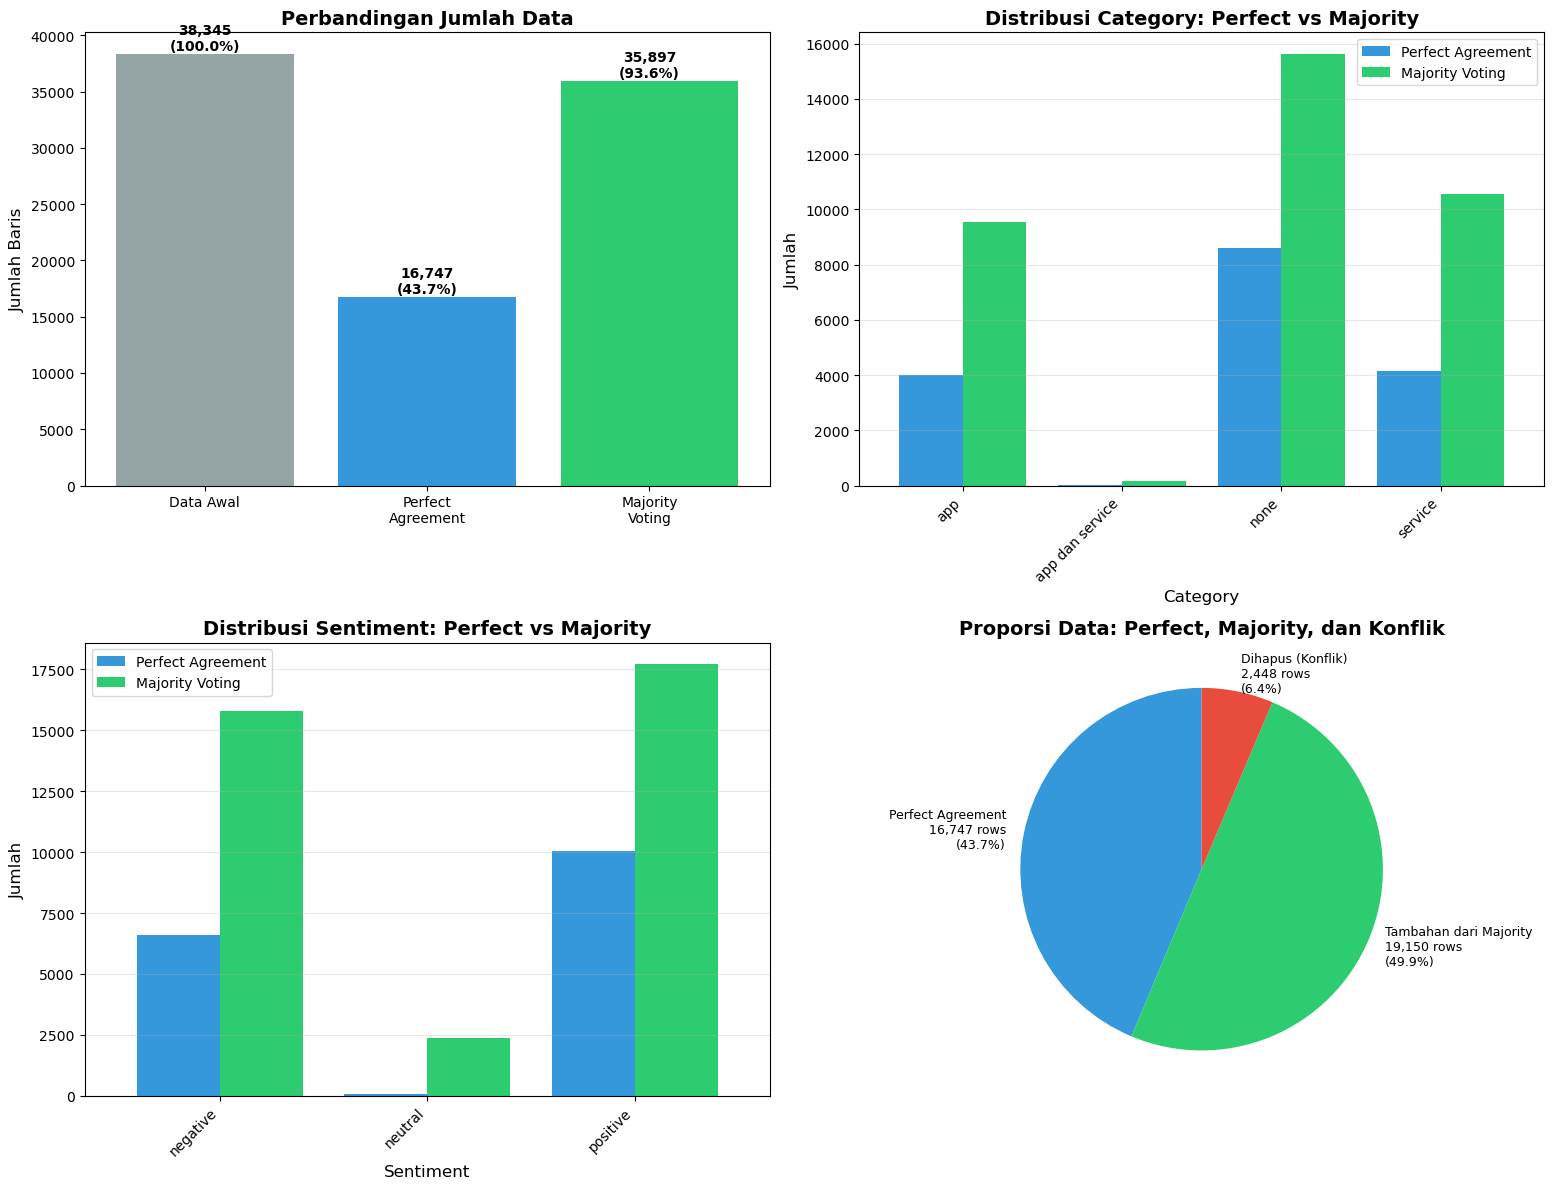


✓ Visualisasi disimpan: comparison_perfect_vs_majority.png


In [40]:
# 4. VISUALISASI PERBANDINGAN
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Jumlah Total Data
ax1 = axes[0, 0]
categories_bar = ['Data Awal', 'Perfect\nAgreement', 'Majority\nVoting']
values_bar = [jumlah_total, jumlah_perfect, jumlah_majority]
colors_bar = ['#95a5a6', '#3498db', '#2ecc71']
bars = ax1.bar(categories_bar, values_bar, color=colors_bar)
ax1.set_ylabel('Jumlah Baris', fontsize=12)
ax1.set_title('Perbandingan Jumlah Data', fontsize=14, fontweight='bold')
for bar, val in zip(bars, values_bar):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{val:,}\n({val/jumlah_total*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 2: Distribusi Category
ax2 = axes[0, 1]
comparison_category[['Perfect Agreement', 'Majority Voting']].plot(
    kind='bar', ax=ax2, color=['#3498db', '#2ecc71'], width=0.8
)
ax2.set_ylabel('Jumlah', fontsize=12)
ax2.set_title('Distribusi Category: Perfect vs Majority', fontsize=14, fontweight='bold')
ax2.legend(['Perfect Agreement', 'Majority Voting'], fontsize=10)
ax2.set_xlabel('Category', fontsize=12)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Distribusi Sentiment
ax3 = axes[1, 0]
comparison_sentiment[['Perfect Agreement', 'Majority Voting']].plot(
    kind='bar', ax=ax3, color=['#3498db', '#2ecc71'], width=0.8
)
ax3.set_ylabel('Jumlah', fontsize=12)
ax3.set_title('Distribusi Sentiment: Perfect vs Majority', fontsize=14, fontweight='bold')
ax3.legend(['Perfect Agreement', 'Majority Voting'], fontsize=10)
ax3.set_xlabel('Sentiment', fontsize=12)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Pie chart - Perbandingan Data Retention
ax4 = axes[1, 1]
pie_labels = [
    f'Perfect Agreement\n{jumlah_perfect:,} rows\n({jumlah_perfect/jumlah_total*100:.1f}%)',
    f'Tambahan dari Majority\n{jumlah_majority-jumlah_perfect:,} rows\n({(jumlah_majority-jumlah_perfect)/jumlah_total*100:.1f}%)',
    f'Dihapus (Konflik)\n{jumlah_total-jumlah_majority:,} rows\n({(jumlah_total-jumlah_majority)/jumlah_total*100:.1f}%)'
]
pie_values = [jumlah_perfect, jumlah_majority-jumlah_perfect, jumlah_total-jumlah_majority]
pie_colors = ['#3498db', '#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax4.pie(
    pie_values, labels=pie_labels, autopct='', colors=pie_colors, 
    startangle=90, textprops={'fontsize': 9}
)
ax4.set_title('Proporsi Data: Perfect, Majority, dan Konflik', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_perfect_vs_majority.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Visualisasi disimpan: comparison_perfect_vs_majority.png")

In [41]:
# 3. PERBEDAAN PER SENTIMENT
print("\n" + "="*80)
print("3. PERBEDAAN DISTRIBUSI SENTIMENT")
print("="*80)

sentiment_perfect = dataset_perfect_agreement['sentiment'].value_counts().sort_index()
sentiment_majority = dataset_majority_voting['sentiment'].value_counts().sort_index()

comparison_sentiment = pd.DataFrame({
    'Perfect Agreement': sentiment_perfect,
    'Majority Voting': sentiment_majority
}).fillna(0).astype(int)

comparison_sentiment['Selisih'] = comparison_sentiment['Majority Voting'] - comparison_sentiment['Perfect Agreement']
comparison_sentiment['% Tambahan'] = (comparison_sentiment['Selisih'] / comparison_sentiment['Perfect Agreement'] * 100).round(2)

print("\nDistribusi Sentiment:")
print(comparison_sentiment)
print(f"\nTotal sentiment di Perfect Agreement: {comparison_sentiment['Perfect Agreement'].sum()}")
print(f"Total sentiment di Majority Voting:   {comparison_sentiment['Majority Voting'].sum()}")


3. PERBEDAAN DISTRIBUSI SENTIMENT

Distribusi Sentiment:
           Perfect Agreement  Majority Voting  Selisih  % Tambahan
sentiment                                                         
negative                6594            15798     9204      139.58
neutral                   90             2379     2289     2543.33
positive               10063            17720     7657       76.09

Total sentiment di Perfect Agreement: 16747
Total sentiment di Majority Voting:   35897


In [42]:
# 2. PERBEDAAN PER CATEGORY
print("\n" + "="*80)
print("2. PERBEDAAN DISTRIBUSI CATEGORY")
print("="*80)

category_perfect = dataset_perfect_agreement['category'].value_counts().sort_index()
category_majority = dataset_majority_voting['category'].value_counts().sort_index()

comparison_category = pd.DataFrame({
    'Perfect Agreement': category_perfect,
    'Majority Voting': category_majority
}).fillna(0).astype(int)

comparison_category['Selisih'] = comparison_category['Majority Voting'] - comparison_category['Perfect Agreement']
comparison_category['% Tambahan'] = (comparison_category['Selisih'] / comparison_category['Perfect Agreement'] * 100).round(2)

print("\nDistribusi Category:")
print(comparison_category)
print(f"\nTotal category di Perfect Agreement: {comparison_category['Perfect Agreement'].sum()}")
print(f"Total category di Majority Voting:   {comparison_category['Majority Voting'].sum()}")


2. PERBEDAAN DISTRIBUSI CATEGORY

Distribusi Category:
                 Perfect Agreement  Majority Voting  Selisih  % Tambahan
category                                                                
app                           4005             9531     5526      137.98
app dan service                 10              181      171     1710.00
none                          8599            15625     7026       81.71
service                       4133            10560     6427      155.50

Total category di Perfect Agreement: 16747
Total category di Majority Voting:   35897


In [43]:
# 1. PERBEDAAN PER BARIS
print("="*80)
print("1. PERBEDAAN JUMLAH BARIS")
print("="*80)

jumlah_perfect = len(dataset_perfect_agreement)
jumlah_majority = len(dataset_majority_voting)
jumlah_total = len(merged)

print(f"Data awal (total):            {jumlah_total:,} rows")
print(f"Perfect Agreement (output 1): {jumlah_perfect:,} rows ({jumlah_perfect/jumlah_total*100:.2f}%)")
print(f"Majority Voting (output 2):   {jumlah_majority:,} rows ({jumlah_majority/jumlah_total*100:.2f}%)")
print(f"\nSelisih:                      {jumlah_majority - jumlah_perfect:,} rows")
print(f"Majority Voting lebih banyak: {(jumlah_majority - jumlah_perfect)/jumlah_perfect*100:.2f}% dari Perfect Agreement")

1. PERBEDAAN JUMLAH BARIS
Data awal (total):            38,345 rows
Perfect Agreement (output 1): 16,747 rows (43.67%)
Majority Voting (output 2):   35,897 rows (93.62%)

Selisih:                      19,150 rows
Majority Voting lebih banyak: 114.35% dari Perfect Agreement


## Analisis Perbedaan Kedua Dataset

Bandingkan perbedaan antara:
- **Dataset Perfect Agreement** (100% setuju)
- **Dataset Majority Voting** (minimal 2 dari 3 setuju)

In [44]:
# Simpan kedua dataset
dataset_perfect_agreement.to_csv('dataset_perfect_agreement.csv', index=False)
print(f"✓ Dataset Perfect Agreement disimpan: dataset_perfect_agreement.csv ({len(dataset_perfect_agreement)} rows)")

dataset_majority_voting.to_csv('dataset_majority_voting.csv', index=False)
print(f"✓ Dataset Majority Voting disimpan: dataset_majority_voting.csv ({len(dataset_majority_voting)} rows)")

✓ Dataset Perfect Agreement disimpan: dataset_perfect_agreement.csv (16747 rows)
✓ Dataset Majority Voting disimpan: dataset_majority_voting.csv (35897 rows)


In [45]:
# Dataset 2: Majority Voting
# Apply majority voting untuk category dan sentiment
merged['category_majority'] = merged.apply(
    lambda row: get_majority_vote([row['category_1'], row['category_2'], row['category_3']]), 
    axis=1
)

merged['sentiment_majority'] = merged.apply(
    lambda row: get_majority_vote([row['sentiment_1'], row['sentiment_2'], row['sentiment_3']]), 
    axis=1
)

# Jika ada None (semua 3 berbeda), maka konflik
merged['has_conflict'] = (merged['category_majority'].isna()) | (merged['sentiment_majority'].isna())

# Ambil hanya yang tidak konflik (ada majority voting)
dataset_majority_voting = merged[merged['has_conflict'] == False][
    ['sentence_id', 'at', 'content', 'category_majority', 'sentiment_majority']
].copy()
dataset_majority_voting = dataset_majority_voting.rename(columns={
    'category_majority': 'category', 
    'sentiment_majority': 'sentiment'
})

print(f"Dataset Majority Voting: {len(dataset_majority_voting)} rows")
print(f"Data yang dihapus (semua 3 berbeda): {len(merged) - len(dataset_majority_voting)} rows")
print(f"\nPersentase majority voting berhasil: {len(dataset_majority_voting)/len(merged)*100:.2f}%")
print("\nSample Majority Voting:")
dataset_majority_voting.head()

Dataset Majority Voting: 35897 rows
Data yang dihapus (semua 3 berbeda): 2448 rows

Persentase majority voting berhasil: 93.62%

Sample Majority Voting:


,sentence_id,at,content,category,sentiment
0,review_1_1,2025-10-30 23:58:11,"Map suka eror,, driver dimana map dimana..biki...",app,negative
1,review_2_1,2025-10-30 23:42:51,terlalu mahal skrg.,service,negative
2,review_3_1,2025-10-30 23:34:57,bolehh lah,none,positive
3,review_4_1,2025-10-30 23:28:26,love you gojek....always the best😍,service,positive
4,review_5_1,2025-10-30 23:06:34,mantap gojek,service,positive


## Dataset 2: Majority Voting

Ambil data dimana **minimal 2 dari 3 annotator setuju** (baik di category DAN sentiment).
Jika **semua 3 berbeda** (di category ATAU sentiment) → HAPUS baris tersebut.

In [46]:
# Dataset 1: Perfect Agreement - semua 3 annotator harus sama persis
# Cek apakah category sama semua DAN sentiment sama semua
merged['category_perfect'] = (merged['category_1'] == merged['category_2']) & (merged['category_2'] == merged['category_3'])
merged['sentiment_perfect'] = (merged['sentiment_1'] == merged['sentiment_2']) & (merged['sentiment_2'] == merged['sentiment_3'])

# Perfect agreement = category perfect DAN sentiment perfect
merged['is_perfect_agreement'] = merged['category_perfect'] & merged['sentiment_perfect']

# Ambil hanya yang perfect agreement
dataset_perfect_agreement = merged[merged['is_perfect_agreement'] == True][
    ['sentence_id', 'at', 'content', 'category_1', 'sentiment_1']
].copy()
dataset_perfect_agreement = dataset_perfect_agreement.rename(columns={
    'category_1': 'category', 
    'sentiment_1': 'sentiment'
})

print(f"Dataset Perfect Agreement: {len(dataset_perfect_agreement)} rows")
print(f"Data yang dihapus (ada perbedaan): {len(merged) - len(dataset_perfect_agreement)} rows")
print(f"\nPersentase perfect agreement: {len(dataset_perfect_agreement)/len(merged)*100:.2f}%")
print("\nSample Perfect Agreement:")
dataset_perfect_agreement.head()

Dataset Perfect Agreement: 16747 rows
Data yang dihapus (ada perbedaan): 21598 rows

Persentase perfect agreement: 43.67%

Sample Perfect Agreement:


,sentence_id,at,content,category,sentiment
3,review_4_1,2025-10-30 23:28:26,love you gojek....always the best😍,service,positive
4,review_5_1,2025-10-30 23:06:34,mantap gojek,service,positive
5,review_6_1,2025-10-30 23:01:26,siip,none,positive
6,review_7_1,2025-10-30 22:33:30,"keren, sangat membantu makasih gojek",service,positive
7,review_8_1,2025-10-30 21:49:06,kalau order gofod jam pagi driver nya masih pa...,service,negative


## Dataset 1: Perfect Agreement (Bebas Konflik)

Hanya ambil data dimana **SEMUA 3 annotator 100% setuju** (baik category DAN sentiment sama persis).
Jika ada **1 saja perbedaan** → HAPUS baris tersebut.

In [47]:
# Tampilkan sample data
print("="*80)
print("SAMPLE DATA MERGED:")
print("="*80)
merged[['sentence_id', 'content', 'category_1', 'category_2', 'category_3', 
        'sentiment_1', 'sentiment_2', 'sentiment_3']].head(10)

SAMPLE DATA MERGED:


,sentence_id,content,category_1,category_2,category_3,sentiment_1,sentiment_2,sentiment_3
0,review_1_1,"Map suka eror,, driver dimana map dimana..biki...",app,app,app dan service,negative,negative,negative
1,review_2_1,terlalu mahal skrg.,service,service,app,negative,negative,negative
2,review_3_1,bolehh lah,none,none,none,positive,positive,neutral
3,review_4_1,love you gojek....always the best😍,service,service,service,positive,positive,positive
4,review_5_1,mantap gojek,service,service,service,positive,positive,positive
5,review_6_1,siip,none,none,none,positive,positive,positive
6,review_7_1,"keren, sangat membantu makasih gojek",service,service,service,positive,positive,positive
7,review_8_1,kalau order gofod jam pagi driver nya masih pa...,service,service,service,negative,negative,negative
8,review_9_1,kasi harga yg bnr la gjls bgt goride gd 2 kilo...,app,app,app,negative,negative,negative
9,review_10_1,Mantap drivernya ramah sopan pokoknya 🌟 5,service,service,service,positive,positive,positive


In [48]:
# Fungsi untuk majority voting
def get_majority_vote(values):
    """
    Mengembalikan nilai mayoritas dari list.
    Jika semua berbeda, return None (konflik).
    Jika ada 2 yang sama, return nilai mayoritas.
    """
    counter = Counter(values)
    most_common = counter.most_common(1)[0]
    
    # Jika nilai terbanyak muncul >= 2 kali, itu mayoritas
    if most_common[1] >= 2:
        return most_common[0]
    else:
        # Semua berbeda (konflik)
        return None

# Apply majority voting untuk category dan sentiment
merged['category_final'] = merged.apply(
    lambda row: get_majority_vote([row['category_1'], row['category_2'], row['category_3']]), 
    axis=1
)

merged['sentiment_final'] = merged.apply(
    lambda row: get_majority_vote([row['sentiment_1'], row['sentiment_2'], row['sentiment_3']]), 
    axis=1
)

# Tandai konflik
# Konflik = category_final ATAU sentiment_final adalah None
merged['is_conflict'] = (merged['category_final'].isna()) | (merged['sentiment_final'].isna())

print(f"Total data: {len(merged)}")
print(f"Data dengan konflik: {merged['is_conflict'].sum()}")
print(f"Data tanpa konflik (majority voting berhasil): {(~merged['is_conflict']).sum()}")
print("\nPersentase konflik: {:.2f}%".format(merged['is_conflict'].sum() / len(merged) * 100))

Total data: 38345
Data dengan konflik: 2448
Data tanpa konflik (majority voting berhasil): 35897

Persentase konflik: 6.38%


In [49]:
# Merge data dari 3 annotator berdasarkan sentence_id
# Rename kolom untuk membedakan masing-masing annotator
df1_renamed = df1.rename(columns={'category': 'category_1', 'sentiment': 'sentiment_1'})
df2_renamed = df2.rename(columns={'category': 'category_2', 'sentiment': 'sentiment_2'})
df3_renamed = df3.rename(columns={'category': 'category_3', 'sentiment': 'sentiment_3'})

# Merge berdasarkan sentence_id
merged = df1_renamed[['sentence_id', 'at', 'content', 'category_1', 'sentiment_1']].merge(
    df2_renamed[['sentence_id', 'category_2', 'sentiment_2']], 
    on='sentence_id', 
    how='inner'
).merge(
    df3_renamed[['sentence_id', 'category_3', 'sentiment_3']], 
    on='sentence_id', 
    how='inner'
)

print(f"Merged dataset: {len(merged)} rows")
print("\nSample merged data:")
merged.head(10)

Merged dataset: 38345 rows

Sample merged data:


,sentence_id,at,content,category_1,sentiment_1,category_2,sentiment_2,category_3,sentiment_3
0,review_1_1,2025-10-30 23:58:11,"Map suka eror,, driver dimana map dimana..biki...",app,negative,app,negative,app dan service,negative
1,review_2_1,2025-10-30 23:42:51,terlalu mahal skrg.,service,negative,service,negative,app,negative
2,review_3_1,2025-10-30 23:34:57,bolehh lah,none,positive,none,positive,none,neutral
3,review_4_1,2025-10-30 23:28:26,love you gojek....always the best😍,service,positive,service,positive,service,positive
4,review_5_1,2025-10-30 23:06:34,mantap gojek,service,positive,service,positive,service,positive
5,review_6_1,2025-10-30 23:01:26,siip,none,positive,none,positive,none,positive
6,review_7_1,2025-10-30 22:33:30,"keren, sangat membantu makasih gojek",service,positive,service,positive,service,positive
7,review_8_1,2025-10-30 21:49:06,kalau order gofod jam pagi driver nya masih pa...,service,negative,service,negative,service,negative
8,review_9_1,2025-10-30 19:45:27,kasi harga yg bnr la gjls bgt goride gd 2 kilo...,app,negative,app,negative,app,negative
9,review_10_1,2025-10-30 18:28:38,Mantap drivernya ramah sopan pokoknya 🌟 5,service,positive,service,positive,service,positive


In [50]:
# Load data dari 3 annotator
df1 = pd.read_csv('very_clean_dataset/annotator1_clean.csv')
df2 = pd.read_csv('very_clean_dataset/annotator2_clean.csv')
df3 = pd.read_csv('very_clean_dataset/annotator3_clean.csv')

print(f"Annotator 1: {len(df1)} rows")
print(f"Annotator 2: {len(df2)} rows")
print(f"Annotator 3: {len(df3)} rows")
print("\nSample dari Annotator 1:")
df1.head()

Annotator 1: 38345 rows
Annotator 2: 38345 rows
Annotator 3: 38345 rows

Sample dari Annotator 1:


,sentence_id,at,content,category,sentiment
0,review_1_1,2025-10-30 23:58:11,"Map suka eror,, driver dimana map dimana..biki...",app,negative
1,review_2_1,2025-10-30 23:42:51,terlalu mahal skrg.,service,negative
2,review_3_1,2025-10-30 23:34:57,bolehh lah,none,positive
3,review_4_1,2025-10-30 23:28:26,love you gojek....always the best😍,service,positive
4,review_5_1,2025-10-30 23:06:34,mantap gojek,service,positive


In [51]:
# Import libraries
import pandas as pd
import numpy as np
from collections import Counter

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Majority Voting untuk Dataset Final

Notebook ini melakukan:
1. **Case 1 (Konflik)**: Jika semua 3 annotator berbeda dalam category ATAU sentiment → beri label konflik dan hapus
2. **Case 2 (Majority Voting)**: Jika 2 dari 3 annotator setuju → pilih label mayoritas (tidak ada konflik)
3. Simpan kedua dataset (dengan konflik dan final tanpa konflik)
4. Analisis perbedaan: per baris, per category, per sentiment

# Majority Voting untuk Dataset Final

Notebook ini melakukan:
1. **Case 1 (Konflik)**: Jika semua 3 annotator berbeda dalam category ATAU sentiment → beri label konflik dan hapus
2. **Case 2 (Majority Voting)**: Jika 2 dari 3 annotator setuju → pilih label mayoritas (tidak ada konflik)
3. Simpan kedua dataset (dengan konflik dan final tanpa konflik)
4. Analisis perbedaan: per baris, per category, per sentiment

In [52]:
# Import libraries
import pandas as pd
import numpy as np
from collections import Counter

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [53]:
# Load data dari 3 annotator
df1 = pd.read_csv('very_clean_dataset/annotator1_clean.csv')
df2 = pd.read_csv('very_clean_dataset/annotator2_clean.csv')
df3 = pd.read_csv('very_clean_dataset/annotator3_clean.csv')

print(f"Annotator 1: {len(df1)} rows")
print(f"Annotator 2: {len(df2)} rows")
print(f"Annotator 3: {len(df3)} rows")
print("Sample dari Annotator 1:")
df1.head()

Annotator 1: 38345 rows
Annotator 2: 38345 rows
Annotator 3: 38345 rows
Sample dari Annotator 1:


,sentence_id,at,content,category,sentiment
0,review_1_1,2025-10-30 23:58:11,"Map suka eror,, driver dimana map dimana..biki...",app,negative
1,review_2_1,2025-10-30 23:42:51,terlalu mahal skrg.,service,negative
2,review_3_1,2025-10-30 23:34:57,bolehh lah,none,positive
3,review_4_1,2025-10-30 23:28:26,love you gojek....always the best😍,service,positive
4,review_5_1,2025-10-30 23:06:34,mantap gojek,service,positive


In [54]:
# Merge data dari 3 annotator berdasarkan sentence_id
# Rename kolom untuk membedakan masing-masing annotator
df1_renamed = df1.rename(columns={'category': 'category_1', 'sentiment': 'sentiment_1'})
df2_renamed = df2.rename(columns={'category': 'category_2', 'sentiment': 'sentiment_2'})
df3_renamed = df3.rename(columns={'category': 'category_3', 'sentiment': 'sentiment_3'})

# Merge berdasarkan sentence_id, at, content
merged = df1_renamed[['sentence_id', 'at', 'content', 'category_1', 'sentiment_1']].merge(
    df2_renamed[['sentence_id', 'category_2', 'sentiment_2']], 
    on='sentence_id', 
    how='inner'
).merge(
    df3_renamed[['sentence_id', 'category_3', 'sentiment_3']], 
    on='sentence_id', 
    how='inner'
)

print(f"Merged dataset: {len(merged)} rows")
print("Sample merged data:")
merged.head(10)

Merged dataset: 38345 rows
Sample merged data:


,sentence_id,at,content,category_1,sentiment_1,category_2,sentiment_2,category_3,sentiment_3
0,review_1_1,2025-10-30 23:58:11,"Map suka eror,, driver dimana map dimana..biki...",app,negative,app,negative,app dan service,negative
1,review_2_1,2025-10-30 23:42:51,terlalu mahal skrg.,service,negative,service,negative,app,negative
2,review_3_1,2025-10-30 23:34:57,bolehh lah,none,positive,none,positive,none,neutral
3,review_4_1,2025-10-30 23:28:26,love you gojek....always the best😍,service,positive,service,positive,service,positive
4,review_5_1,2025-10-30 23:06:34,mantap gojek,service,positive,service,positive,service,positive
5,review_6_1,2025-10-30 23:01:26,siip,none,positive,none,positive,none,positive
6,review_7_1,2025-10-30 22:33:30,"keren, sangat membantu makasih gojek",service,positive,service,positive,service,positive
7,review_8_1,2025-10-30 21:49:06,kalau order gofod jam pagi driver nya masih pa...,service,negative,service,negative,service,negative
8,review_9_1,2025-10-30 19:45:27,kasi harga yg bnr la gjls bgt goride gd 2 kilo...,app,negative,app,negative,app,negative
9,review_10_1,2025-10-30 18:28:38,Mantap drivernya ramah sopan pokoknya 🌟 5,service,positive,service,positive,service,positive


In [55]:
# Fungsi untuk majority voting
def get_majority_vote(values):
    """
    Mengembalikan nilai mayoritas dari list.
    Jika semua berbeda, return None (konflik).
    Jika ada 2 yang sama, return nilai mayoritas.
    """
    counter = Counter(values)
    most_common = counter.most_common(1)[0]
    
    # Jika nilai terbanyak muncul >= 2 kali, itu mayoritas
    if most_common[1] >= 2:
        return most_common[0]
    else:
        # Semua berbeda (konflik)
        return None

# Apply majority voting untuk category dan sentiment
merged['category_final'] = merged.apply(
    lambda row: get_majority_vote([row['category_1'], row['category_2'], row['category_3']]), 
    axis=1
)

merged['sentiment_final'] = merged.apply(
    lambda row: get_majority_vote([row['sentiment_1'], row['sentiment_2'], row['sentiment_3']]), 
    axis=1
)

# Tandai konflik
# Konflik = category_final ATAU sentiment_final adalah None
merged['is_conflict'] = (merged['category_final'].isna()) | (merged['sentiment_final'].isna())

print(f"Total data: {len(merged)}")
print(f"Data dengan konflik: {merged['is_conflict'].sum()}")
print(f"Data tanpa konflik (majority voting berhasil): {(~merged['is_conflict']).sum()}")
print("Persentase konflik: {:.2f}%".format(merged['is_conflict'].sum() / len(merged) * 100))

Total data: 38345
Data dengan konflik: 2448
Data tanpa konflik (majority voting berhasil): 35897
Persentase konflik: 6.38%


In [56]:
# Tampilkan sample data konflik
print("=" * 80)
print("SAMPLE DATA KONFLIK (Semua 3 annotator berbeda):")
print("=" * 80)
conflict_data = merged[merged['is_conflict'] == True]
if len(conflict_data) > 0:
    display(conflict_data[['sentence_id', 'content', 
                           'category_1', 'category_2', 'category_3', 'category_final',
                           'sentiment_1', 'sentiment_2', 'sentiment_3', 'sentiment_final']].head(10))
else:
    print("Tidak ada data konflik!")

print("" + "=" * 80)
print("SAMPLE DATA MAJORITY VOTING (2 dari 3 annotator setuju):")
print("=" * 80)
non_conflict_data = merged[merged['is_conflict'] == False]
if len(non_conflict_data) > 0:
    display(non_conflict_data[['sentence_id', 'content', 
                                'category_1', 'category_2', 'category_3', 'category_final',
                                'sentiment_1', 'sentiment_2', 'sentiment_3', 'sentiment_final']].head(10))
else:
    print("Tidak ada data majority voting!")

SAMPLE DATA KONFLIK (Semua 3 annotator berbeda):


,sentence_id,content,category_1,category_2,category_3,category_final,sentiment_1,sentiment_2,sentiment_3,sentiment_final
58,review_47_1,aplikasi nya kalau kondisi cuaca hujan susah n...,service,app,app dan service,None,negative,negative,negative,negative
91,review_79_1,membantu banget dan murah murah lagi tapi kala...,app,service,app,app,negative,neutral,positive,None
99,review_85_1,mohon gojek foto profil di aplikasi go-jek seh...,service,app,app,app,negative,positive,neutral,None
149,review_127_1,mantappppp yakin deh pakai gojek aja aplikasi ...,app,app dan service,service,None,positive,positive,positive,positive
166,review_141_1,tlg d atikan yaplikasiny golek y,service,app,none,None,negative,negative,neutral,negative
167,review_142_1,"ada beberapa opsi dimana sangat menjengkelkan,...",app,service,app dan service,None,negative,negative,negative,negative
186,review_157_1,"sulit batal order makan, gosend susah hubungi ...",service,app,app dan service,None,negative,negative,negative,negative
190,review_160_2,"PADAHAL HUJAN UDAH BERHENTI, UDAH NUNGGU SEJAM...",service,app,app dan service,None,negative,negative,negative,negative
213,review_177_1,"UDAH TAU BATALIN BOOKING KARENA JAUH, MALAH DI...",app,service,app dan service,None,negative,negative,negative,negative
214,review_178_1,penyediaan driver sering terlalu jauh dari lok...,app,service,app dan service,None,negative,negative,negative,negative


SAMPLE DATA MAJORITY VOTING (2 dari 3 annotator setuju):


,sentence_id,content,category_1,category_2,category_3,category_final,sentiment_1,sentiment_2,sentiment_3,sentiment_final
0,review_1_1,"Map suka eror,, driver dimana map dimana..biki...",app,app,app dan service,app,negative,negative,negative,negative
1,review_2_1,terlalu mahal skrg.,service,service,app,service,negative,negative,negative,negative
2,review_3_1,bolehh lah,none,none,none,none,positive,positive,neutral,positive
3,review_4_1,love you gojek....always the best😍,service,service,service,service,positive,positive,positive,positive
4,review_5_1,mantap gojek,service,service,service,service,positive,positive,positive,positive
5,review_6_1,siip,none,none,none,none,positive,positive,positive,positive
6,review_7_1,"keren, sangat membantu makasih gojek",service,service,service,service,positive,positive,positive,positive
7,review_8_1,kalau order gofod jam pagi driver nya masih pa...,service,service,service,service,negative,negative,negative,negative
8,review_9_1,kasi harga yg bnr la gjls bgt goride gd 2 kilo...,app,app,app,app,negative,negative,negative,negative
9,review_10_1,Mantap drivernya ramah sopan pokoknya 🌟 5,service,service,service,service,positive,positive,positive,positive


In [57]:
# Simpan dataset dengan konflik (untuk referensi)
dataset_with_conflict = merged[['sentence_id', 'at', 'content', 
                                 'category_1', 'category_2', 'category_3', 'category_final',
                                 'sentiment_1', 'sentiment_2', 'sentiment_3', 'sentiment_final',
                                 'is_conflict']].copy()

dataset_with_conflict.to_csv('dataset_with_conflict.csv', index=False)
print(f"✓ Dataset dengan label konflik disimpan: dataset_with_conflict.csv ({len(dataset_with_conflict)} rows)")

# Simpan dataset final (tanpa konflik - hanya majority voting)
dataset_final = merged[merged['is_conflict'] == False][['sentence_id', 'at', 'content', 
                                                          'category_final', 'sentiment_final']].copy()
dataset_final = dataset_final.rename(columns={'category_final': 'category', 'sentiment_final': 'sentiment'})

dataset_final.to_csv('dataset_final_majority_voting.csv', index=False)
print(f"✓ Dataset final (tanpa konflik) disimpan: dataset_final_majority_voting.csv ({len(dataset_final)} rows)")

print(f"Data yang dihapus (konflik): {len(dataset_with_conflict) - len(dataset_final)} rows")

✓ Dataset dengan label konflik disimpan: dataset_with_conflict.csv (38345 rows)
✓ Dataset final (tanpa konflik) disimpan: dataset_final_majority_voting.csv (35897 rows)
Data yang dihapus (konflik): 2448 rows


## Analisis Perbedaan Data

Bandingkan perbedaan antara:
- **Dataset dengan konflik** (semua data termasuk yang konflik)
- **Dataset final** (hanya data majority voting, konflik dihapus)

In [58]:
# 1. PERBEDAAN PER BARIS
print("=" * 80)
print("1. PERBEDAAN JUMLAH BARIS")
print("=" * 80)

jumlah_total = len(dataset_with_conflict)
jumlah_final = len(dataset_final)
jumlah_konflik = dataset_with_conflict['is_conflict'].sum()

print(f"Dataset dengan konflik (semua data): {jumlah_total:,} rows")
print(f"Dataset final (tanpa konflik):       {jumlah_final:,} rows")
print(f"Data yang dihapus (konflik):         {jumlah_konflik:,} rows")
print(f"Persentase data yang dipertahankan: {jumlah_final/jumlah_total*100:.2f}%")
print(f"Persentase data yang dihapus:       {jumlah_konflik/jumlah_total*100:.2f}%")

1. PERBEDAAN JUMLAH BARIS
Dataset dengan konflik (semua data): 38,345 rows
Dataset final (tanpa konflik):       35,897 rows
Data yang dihapus (konflik):         2,448 rows
Persentase data yang dipertahankan: 93.62%
Persentase data yang dihapus:       6.38%


In [59]:
# 2. PERBEDAAN PER CATEGORY
print("" + "=" * 80)
print("2. PERBEDAAN DISTRIBUSI CATEGORY")
print("=" * 80)

# Category di dataset dengan konflik (gunakan category_final, skip yang None)
category_with_conflict = dataset_with_conflict[dataset_with_conflict['category_final'].notna()]['category_final'].value_counts().sort_index()

# Category di dataset final
category_final = dataset_final['category'].value_counts().sort_index()

# Gabungkan untuk perbandingan
comparison_category = pd.DataFrame({
    'Dengan Konflik (non-null)': category_with_conflict,
    'Final (tanpa konflik)': category_final
}).fillna(0).astype(int)

comparison_category['Selisih'] = comparison_category['Dengan Konflik (non-null)'] - comparison_category['Final (tanpa konflik)']
comparison_category['% Perubahan'] = (comparison_category['Selisih'] / comparison_category['Dengan Konflik (non-null)'] * 100).round(2)

print("" + "=" * 80)Distribusi Category:")
print(comparison_category)

# Tampilkan juga yang konflik category (semua 3 berbeda)
category_conflict_count = dataset_with_conflict[dataset_with_conflict['category_final'].isna()].shape[0]
print(f"
Data dengan konflik category (3 annotator berbeda): {category_conflict_count}")

SyntaxError: unterminated string literal (detected at line 21) (1293302708.py, line 21)

In [ ]:
# 3. PERBEDAAN PER SENTIMENT
print("" + "=" * 80)
print("3. PERBEDAAN DISTRIBUSI SENTIMENT")
print("=" * 80)

# Sentiment di dataset dengan konflik (gunakan sentiment_final, skip yang None)
sentiment_with_conflict = dataset_with_conflict[dataset_with_conflict['sentiment_final'].notna()]['sentiment_final'].value_counts().sort_index()

# Sentiment di dataset final
sentiment_final = dataset_final['sentiment'].value_counts().sort_index()

# Gabungkan untuk perbandingan
comparison_sentiment = pd.DataFrame({
    'Dengan Konflik (non-null)': sentiment_with_conflict,
    'Final (tanpa konflik)': sentiment_final
}).fillna(0).astype(int)

comparison_sentiment['Selisih'] = comparison_sentiment['Dengan Konflik (non-null)'] - comparison_sentiment['Final (tanpa konflik)']
comparison_sentiment['% Perubahan'] = (comparison_sentiment['Selisih'] / comparison_sentiment['Dengan Konflik (non-null)'] * 100).round(2)

print("
Distribusi Sentiment:")
print(comparison_sentiment)

# Tampilkan juga yang konflik sentiment (semua 3 berbeda)
sentiment_conflict_count = dataset_with_conflict[dataset_with_conflict['sentiment_final'].isna()].shape[0]
print(f"
Data dengan konflik sentiment (3 annotator berbeda): {sentiment_conflict_count}")

In [ ]:
# 4. VISUALISASI PERBANDINGAN
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Jumlah Total Data
ax1 = axes[0, 0]
categories_bar = ['Dataset dengan Konflik', 'Dataset Final', 'Data Dihapus (Konflik)']
values_bar = [jumlah_total, jumlah_final, jumlah_konflik]
colors_bar = ['#3498db', '#2ecc71', '#e74c3c']
ax1.bar(categories_bar, values_bar, color=colors_bar)
ax1.set_ylabel('Jumlah Baris')
ax1.set_title('Perbandingan Jumlah Data')
for i, v in enumerate(values_bar):
    ax1.text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

# Plot 2: Distribusi Category
ax2 = axes[0, 1]
comparison_category[['Dengan Konflik (non-null)', 'Final (tanpa konflik)']].plot(kind='bar', ax=ax2, color=['#3498db', '#2ecc71'])
ax2.set_ylabel('Jumlah')
ax2.set_title('Distribusi Category: Dengan vs Tanpa Konflik')
ax2.legend(['Dengan Konflik', 'Final'])
ax2.set_xlabel('Category')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Plot 3: Distribusi Sentiment
ax3 = axes[1, 0]
comparison_sentiment[['Dengan Konflik (non-null)', 'Final (tanpa konflik)']].plot(kind='bar', ax=ax3, color=['#3498db', '#2ecc71'])
ax3.set_ylabel('Jumlah')
ax3.set_title('Distribusi Sentiment: Dengan vs Tanpa Konflik')
ax3.legend(['Dengan Konflik', 'Final'])
ax3.set_xlabel('Sentiment')
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Plot 4: Pie chart - Data Retention
ax4 = axes[1, 1]
pie_labels = [f'Dipertahankan
({jumlah_final:,})', f'Dihapus (Konflik)
({jumlah_konflik:,})']
pie_values = [jumlah_final, jumlah_konflik]
pie_colors = ['#2ecc71', '#e74c3c']
ax4.pie(pie_values, labels=pie_labels, autopct='%1.1f%%', colors=pie_colors, startangle=90)
ax4.set_title('Proporsi Data yang Dipertahankan vs Dihapus')

plt.tight_layout()
plt.savefig('majority_voting_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("
✓ Visualisasi disimpan: majority_voting_comparison.png")

In [ ]:
# RINGKASAN AKHIR
print("=" * 80)
print("RINGKASAN HASIL MAJORITY VOTING")
print("=" * 80)
print("
📊 FILE OUTPUT:")
print("   1. dataset_with_conflict.csv          - Dataset lengkap dengan label konflik")
print("   2. dataset_final_majority_voting.csv  - Dataset final (hanya majority voting)")
print("   3. majority_voting_comparison.png     - Visualisasi perbandingan")

print("
📈 STATISTIK:")
print(f"   • Total data awal: {jumlah_total:,} rows")
print(f"   • Data final (dipertahankan): {jumlah_final:,} rows ({jumlah_final/jumlah_total*100:.2f}%)")
print(f"   • Data konflik (dihapus): {jumlah_konflik:,} rows ({jumlah_konflik/jumlah_total*100:.2f}%)")

print("
🎯 CASE YANG DITERAPKAN:")
print("   • Case 1: Konflik (semua 3 annotator berbeda) → Label konflik & dihapus")
print("   • Case 2: Majority voting (2 dari 3 setuju) → Pilih label mayoritas")

print("
✅ Selesai!")